# Minimal toy tutorial: Lund plane declustering (Section 2)

This notebook walks through the declustering procedure described in **Section 2** of *“Jet tagging in the Lund plane with graph networks”* by Dreyer & Qu (arXiv:2012.08526v2). It follows the algorithm in that section and computes the tuple  
\(T^{(i)} = \{k_t,\,\Delta,\,z,\,m,\,\psi\}\) for each declustering node.  

We will **not** use `fastjet` here; instead we implement a tiny **pure-Python Cambridge/Aachen (C/A)** reclustering for a handful of massless toy particles, just to understand each step.

> Reference: algorithm steps and variable definitions are from Section 2 and Eq. (2.1) of the paper.


## 0. Setup

We represent each constituent by \((p_T, y, \phi)\).  
We treat particles as **massless**, build 4-vectors, and define:

- \(\Delta \equiv \sqrt{(y_a-y_b)^2 + (\phi_a-\phi_b)^2}\)
- **C/A distance:** choose the pair with smallest \(\Delta\) and merge
- After reclustering, we **decluster** the C/A tree: at each node split into two children, order them such that \(p_{T,a} > p_{T,b}\), and treat **b as the emission** from the (a+b) parent.

For each declustering step:

- \(k_t = p_{T,b}\,\Delta\)
- \(z = \frac{p_{T,b}}{p_{T,a}+p_{T,b}}\)
- \(m\) = invariant mass of the pair (the parent mass)
- \(\psi = \tan^{-1}\left(\frac{y_b-y_a}{\phi_b-\phi_a}\right)\) (using wrapped \(\Delta\phi\))


In [1]:
import math
from dataclasses import dataclass
from typing import Optional, List, Tuple, Dict

def delta_phi(phi1: float, phi2: float) -> float:
    """Return phi1-phi2 wrapped into (-pi, pi]."""
    d = phi1 - phi2
    while d <= -math.pi:
        d += 2*math.pi
    while d > math.pi:
        d -= 2*math.pi
    return d

def delta_R2(y1: float, phi1: float, y2: float, phi2: float) -> float:
    dphi = delta_phi(phi1, phi2)
    dy = y1 - y2
    return dy*dy + dphi*dphi

@dataclass
class PseudoJet:
    px: float
    py: float
    pz: float
    E: float
    left: Optional['PseudoJet']=None
    right: Optional['PseudoJet']=None
    label: Optional[str]=None  # for leaves

    @property
    def pt(self) -> float:
        return math.hypot(self.px, self.py)

    @property
    def phi(self) -> float:
        return math.atan2(self.py, self.px)

    @property
    def y(self) -> float:
        # rapidity y = 0.5 ln((E+pz)/(E-pz))
        # guard against numerical issues
        num = self.E + self.pz
        den = self.E - self.pz
        if den <= 0 or num <= 0:
            # fallback: treat as large rapidity; for toy examples this shouldn't happen
            return float('inf') if num > den else float('-inf')
        return 0.5*math.log(num/den)

    @property
    def mass2(self) -> float:
        return max(0.0, self.E*self.E - (self.px*self.px + self.py*self.py + self.pz*self.pz))

    @property
    def mass(self) -> float:
        return math.sqrt(self.mass2)

def massless_pjet(pt: float, y: float, phi: float, label: str=None) -> PseudoJet:
    """Build a massless 4-vector from (pt, y, phi)."""
    px = pt*math.cos(phi)
    py = pt*math.sin(phi)
    pz = pt*math.sinh(y)
    E  = pt*math.cosh(y)
    return PseudoJet(px=px, py=py, pz=pz, E=E, label=label)

def merge(a: PseudoJet, b: PseudoJet) -> PseudoJet:
    return PseudoJet(px=a.px+b.px, py=a.py+b.py, pz=a.pz+b.pz, E=a.E+b.E, left=a, right=b)


## 1. Minimal C/A reclustering (toy)

C/A clustering repeatedly merges the pair with the smallest \(\Delta\) (equivalently smallest \(\Delta^2\)).  
We keep the full **binary tree** (each merged node stores pointers to its two children).

This is a *tiny* implementation meant only for educational toy inputs (N=3–8), not for real jets.


In [2]:
def ca_cluster(pjets: List[PseudoJet], verbose: bool=True) -> PseudoJet:
    """Naive Cambridge/Aachen reclustering: repeatedly merge closest pair in (y,phi)."""
    nodes = pjets[:]
    step = 0
    while len(nodes) > 1:
        # find closest pair
        best = None
        best_i = best_j = None
        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                d2 = delta_R2(nodes[i].y, nodes[i].phi, nodes[j].y, nodes[j].phi)
                if (best is None) or (d2 < best):
                    best = d2
                    best_i, best_j = i, j
        a, b = nodes[best_i], nodes[best_j]
        parent = merge(a, b)
        if verbose:
            print(f"Step {step}: merge ({a.label or 'node'} , {b.label or 'node'})  Δ={math.sqrt(best):.3f}")
        # remove j first to keep indices stable
        for idx in sorted([best_i, best_j], reverse=True):
            nodes.pop(idx)
        nodes.append(parent)
        step += 1
    return nodes[0]


## 2. Declustering and Lund tuple extraction

Starting from the final jet node:

1. **Decluster** into two children.
2. Order them by transverse momentum so that \(p_{T,a} > p_{T,b}\).
3. Compute \(T^{(i)}=\{k_t,\Delta,z,m,\psi\}\).
4. Recurse on both children that are not leaves.

The paper also defines the **primary branch**: keep following the harder branch \(a\) at each split.


In [3]:
def lund_tuples(root: PseudoJet) -> List[Dict]:
    """Return list of declustering tuples for all internal nodes, with parent->(a,b) ordered by pt."""
    out = []
    def rec(node: PseudoJet):
        if node.left is None or node.right is None:
            return
        c1, c2 = node.left, node.right
        # order by pt: a is harder, b is softer
        a, b = (c1, c2) if c1.pt >= c2.pt else (c2, c1)
        dy = b.y - a.y
        dphi = delta_phi(b.phi, a.phi)  # (phi_b - phi_a) wrapped
        Delta = math.sqrt(dy*dy + dphi*dphi)
        kt = b.pt * Delta
        z = b.pt / (a.pt + b.pt) if (a.pt + b.pt) > 0 else float('nan')
        m = node.mass
        psi = math.atan2(dy, dphi)  # arctan( (y_b-y_a)/(phi_b-phi_a) ) with correct quadrant
        out.append({
            'node_id': id(node),
            'pt_parent': node.pt,
            'pt_a': a.pt, 'pt_b': b.pt,
            'y_a': a.y, 'phi_a': a.phi,
            'y_b': b.y, 'phi_b': b.phi,
            'Delta': Delta,
            'kt': kt,
            'z': z,
            'm': m,
            'psi': psi,
            'a_is_leaf': (a.left is None and a.right is None),
            'b_is_leaf': (b.left is None and b.right is None),
            'a_label': a.label,
            'b_label': b.label,
        })
        rec(a)
        rec(b)
    rec(root)
    return out

def primary_branch(root: PseudoJet) -> List[Dict]:
    """Follow the harder branch only (primary Lund sequence) and return its tuples."""
    seq = []
    node = root
    while node.left is not None and node.right is not None:
        c1, c2 = node.left, node.right
        a, b = (c1, c2) if c1.pt >= c2.pt else (c2, c1)
        dy = b.y - a.y
        dphi = delta_phi(b.phi, a.phi)
        Delta = math.sqrt(dy*dy + dphi*dphi)
        kt = b.pt * Delta
        z = b.pt / (a.pt + b.pt) if (a.pt + b.pt) > 0 else float('nan')
        m = node.mass
        psi = math.atan2(dy, dphi)
        seq.append({'kt': kt, 'Delta': Delta, 'z': z, 'm': m, 'psi': psi, 'a_label': a.label, 'b_label': b.label})
        node = a
    return seq


## 3. Toy example A: 4 constituents

We choose 4 massless constituents with simple \((p_T,y,\phi)\).  
Two are close to each other, so you can see how C/A merges “nearest in angle” first.

Feel free to edit the numbers to build intuition.


In [4]:
toy_particles = [
    massless_pjet(pt=50, y=0.10, phi=0.05, label='p1'),
    massless_pjet(pt=30, y=0.12, phi=0.02, label='p2'),  # close to p1
    massless_pjet(pt=25, y=-0.30, phi=1.00, label='p3'),
    massless_pjet(pt=15, y=-0.28, phi=1.10, label='p4'), # close to p3
]

root = ca_cluster(toy_particles, verbose=True)
print("\nFinal jet:", f"pt={root.pt:.2f}, y={root.y:.2f}, phi={root.phi:.2f}, m={root.mass:.2f}")

Step 0: merge (p1 , p2)  Δ=0.036
Step 1: merge (p3 , p4)  Δ=0.102
Step 2: merge (node , node)  Δ=1.076

Final jet: pt=107.03, y=-0.03, phi=0.36, m=58.86


### 3.1 All declusterings (full Lund tree)

Each internal node corresponds to one declustering and one tuple \(T^{(i)}\).


In [5]:
tuples = lund_tuples(root)
import pandas as pd
df = pd.DataFrame(tuples)[['pt_parent','pt_a','pt_b','a_label','b_label','Delta','kt','z','m','psi']]
df

,pt_parent,pt_a,pt_b,a_label,b_label,Delta,kt,z,m,psi
0,107.028953,79.991563,39.953137,NaN,NaN,1.075863,42.984107,0.333096,58.864803,-0.380941
1,79.991563,50.000000,30.000000,p1,p2,0.036056,1.081665,0.375000,1.396395,2.553590
2,39.953137,25.000000,15.000000,p3,p4,0.101980,1.529706,0.375000,1.974052,0.197396


### 3.2 Primary Lund sequence

This follows the **harder branch** at each split (the blue “primary” line in the paper’s Fig. 1).


In [6]:
prim = pd.DataFrame(primary_branch(root))
prim

,kt,Delta,z,m,psi,a_label,b_label
0,42.984107,1.075863,0.333096,58.864803,-0.380941,NaN,NaN
1,1.081665,0.036056,0.375000,1.396395,2.553590,p1,p2


## 4. Plotting the Lund plane points

The usual Lund plane axes are \(\ln(1/\Delta)\) and \(\ln k_t\) (often with GeV units for \(k_t\)).  
Below we plot *all* declusterings (full tree) and highlight the primary sequence.


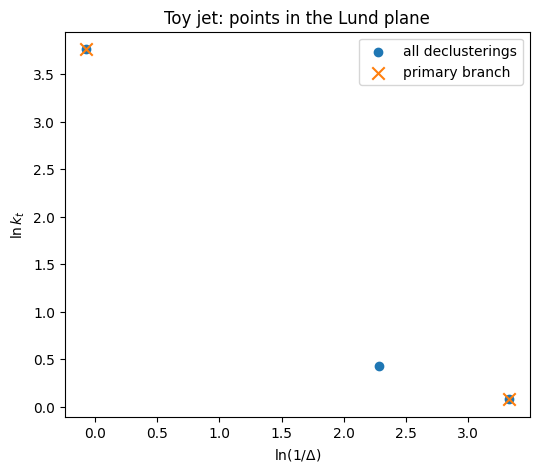

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# all points
lnkt = np.log([t['kt'] for t in tuples])
lninvDelta = np.log([1.0/t['Delta'] for t in tuples])

# primary points: pick from prim, but we need kt/Delta list
lnkt_p = np.log(prim['kt'].values)
lninvDelta_p = np.log(1.0/prim['Delta'].values)

plt.figure(figsize=(6,5))
plt.scatter(lninvDelta, lnkt, label='all declusterings')
plt.scatter(lninvDelta_p, lnkt_p, marker='x', s=80, label='primary branch')
plt.xlabel(r'$\ln(1/\Delta)$')
plt.ylabel(r'$\ln k_t$')
plt.legend()
plt.title('Toy jet: points in the Lund plane')
plt.show()

## 5. Step-by-step printout for one declustering

To connect directly to the paper’s step (1)–(3), here is a verbose view for each declustering:

- identify (a,b) ordered by \(p_T\)
- compute \(\Delta, k_t, z, m, \psi\)
- see which side is treated as the emission (the softer branch b)


In [8]:
def pretty_tuple(t: Dict, i: int):
    return (
        f"Declustering {i}: parent pt={t['pt_parent']:.2f}\n"
        f"  a (hard) = {t['a_label'] or 'node'}  pt={t['pt_a']:.2f}\n"
        f"  b (soft) = {t['b_label'] or 'node'}  pt={t['pt_b']:.2f}   <-- emission\n"
        f"  Δ={t['Delta']:.3f}  kt={t['kt']:.2f}  z={t['z']:.3f}  m={t['m']:.2f}  ψ={t['psi']:.2f}\n"
    )

for i, t in enumerate(tuples):
    print(pretty_tuple(t, i))


Declustering 0: parent pt=107.03
  a (hard) = node  pt=79.99
  b (soft) = node  pt=39.95   <-- emission
  Δ=1.076  kt=42.98  z=0.333  m=58.86  ψ=-0.38

Declustering 1: parent pt=79.99
  a (hard) = p1  pt=50.00
  b (soft) = p2  pt=30.00   <-- emission
  Δ=0.036  kt=1.08  z=0.375  m=1.40  ψ=2.55

Declustering 2: parent pt=39.95
  a (hard) = p3  pt=25.00
  b (soft) = p4  pt=15.00   <-- emission
  Δ=0.102  kt=1.53  z=0.375  m=1.97  ψ=0.20



## 6. (Optional) Applying a simple $k_t$ cut

Section 2 mentions that you can remove declusterings below a transverse-momentum threshold in the Lund plane to reduce sensitivity to non-perturbative effects and also shrink the tree.

Here we just demonstrate how many nodes survive a cut in this toy example.


In [9]:
def apply_kt_cut(tuples: List[Dict], kt_min: float) -> pd.DataFrame:
    kept = [t for t in tuples if t['kt'] >= kt_min]
    return pd.DataFrame(kept)[['Delta','kt','z','m','psi','a_label','b_label']]

for kt_min in [0, 5, 10, 20]:
    kept_df = apply_kt_cut(tuples, kt_min)
    print(f"kt_min = {kt_min:>2} : kept {len(kept_df)} / {len(tuples)} nodes")


kt_min =  0 : kept 3 / 3 nodes
kt_min =  5 : kept 1 / 3 nodes
kt_min = 10 : kept 1 / 3 nodes
kt_min = 20 : kept 1 / 3 nodes


## 7. Where to go next

This notebook was deliberately minimal. Natural extensions:

1. Replace the naive C/A with `fastjet` (for real jets).
2. Store the resulting Lund tuples as nodes in a graph, with edges following the binary tree, exactly as described in the paper.
3. Add secondary/tertiary “planes” visualization by coloring points by depth in the tree.

If you want, I can also provide a version that uses `fastjet` + `pyjet` (if available in your environment) and reads a realistic event record.
